# Push-T: inferencia sobre el modelo del articulo

Prueba de humo del punto de control publicado por los autores de *Diffusion Policy*,
en `diffuser/models/V_Paper/epoch=0500-test_mean_score=0.884.ckpt`. Carga el
checkpoint y ejecuta un rollout. Selecciona el kernel Python (.venv_diffuser_infer).

**No es una variante del experimento.** Su encoder no es el de V0-V4:

| | V0-V4 | V_Paper |
|---|---|---|
| politica | `DiffusionUnetImagePolicy` | `DiffusionUnetHybridImagePolicy` |
| encoder | `MultiImageObsEncoder` del repo | encoder de **robomimic** |
| agregacion espacial | promediado global (V0-V2) o token de clase (V3, V4) | **`SpatialSoftmax`**, 32 keypoints, seguido de `Linear(64 -> 64)` |
| recorte | 76x76 (V0) o ninguno (V3, V4) | 84x84, con `eval_fixed_crop` |

Es el *spatial softmax* que ninguna de las cinco variantes del TFM usa. Todo lo demas
coincide: mismo UNet (`down_dims [512, 1024, 2048]`), mismo DDPM de 100 pasos,
`horizon 16`, `n_obs_steps 2`, `n_action_steps 8`, y la misma particion del dataset
(`seed 42`, `val_ratio 0.02`, `max_train_episodes 90`).

**El 0.884 del nombre del fichero no es comparable con las cifras del TFM.** Esta medido
sobre las semillas `4300000-4300049`, no sobre el bloque `100000` de la curva de seleccion
ni sobre el bloque preregistrado `200000-200199` del que salen los resultados
(V0 0,872 - V1 0,649 - V2 0,586 - V3 0,578 - V4 0,490).


In [1]:
from paper_inference_utils import (
    MODEL_DIR,
    default_checkpoint,
    list_checkpoints,
    plot_rollout,
    resolve_device,
    run_rollout,
)
import matplotlib.pyplot as plt

device = resolve_device()
checkpoints = list_checkpoints(MODEL_DIR)
print('Device:', device)
print('Checkpoints:')
for checkpoint in checkpoints:
    print(' -', checkpoint.name)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Device: cuda:0
Checkpoints:
 - epoch=0500-test_mean_score=0.884.ckpt


c:\Users\moise\Documents\0001_MADI\TFM\.venv_diffuser_infer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['agent_pos']
using obs modality: rgb with keys: ['image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []


c:\Users\moise\Documents\0001_MADI\TFM\.venv_diffuser_infer\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\moise\Documents\0001_MADI\TFM\.venv_diffuser_infer\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Diffusion params: 2.515119e+08
Vision params: 1.119709e+07
{'checkpoint': 'epoch=0500-test_mean_score=0.884.ckpt', 'seed': 10049, 'device': 'cuda:0', 'env_steps': 300, 'decision_steps': 38, 'max_reward': 0.9447, 'success': False}


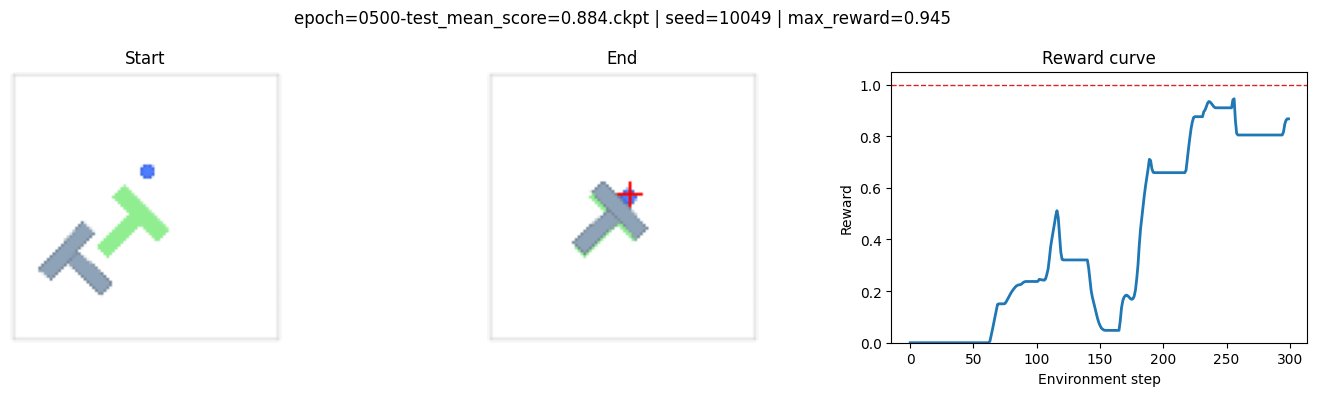

In [2]:
# Semilla 10049, la misma que usan los notebooks de V1 a V4, para poder
# contrastar a ojo el fotograma final.
checkpoint_path = default_checkpoint()
seed = 10049
result = run_rollout(checkpoint_path=checkpoint_path, seed=seed, device=device)
print({
    'checkpoint': result['checkpoint_name'],
    'seed': result['seed'],
    'device': result['device'],
    'env_steps': result['n_env_steps'],
    'decision_steps': result['n_decisions'],
    'max_reward': round(result['max_reward'], 4),
    'success': result['success'],
})
fig = plot_rollout(result)
plt.show()